# CosmicLargeTrain Target Crop 256 Check

This notebook compares `CosmicLargeTrain` with `target_crop_256=False` and `target_crop_256=True`.
It renders 20 sampled rows with the processed training target image, target face bbox, prompt, and reference images.

Path selection tries server paths first and falls back to the local subset paths.

In [1]:
from pathlib import Path
import base64
from io import BytesIO
import html
import random
import sys

import numpy as np
import torch
from PIL import Image, ImageDraw
from IPython.display import HTML, display
from torchvision import transforms

PROJECT_ROOT = Path('/home/kolyangg/rsrch/diffusion_template')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.datasets.cosmic import CosmicLargeTrain

In [17]:
# random seed
SEED = random.randint(0, 100000)

In [18]:
# Tunables
NUM_ROWS = 20
NUM_REFS = 1
MIN_FACE_RES = 192
# SEED = 42

SERVER_CFG = {
    'data_json_pth': '/mnt/virtual_ai0001053-01309_SR006-nfs1/bobkov/cosmic_data/gathered_data_cosmic_large_filtered.json',
    'images_path': '/mnt/virtual_ai0001053-01309_SR006-nfs1/bobkov/cosmic_data/LAION-5B-Filtered-Large-Faces/laion1B-nolang',
    # Leave target_images_path unset on server: CosmicLargeTrain resolves target images via dataset_root.
    'target_images_path': None,
    'path_prefix_to_strip': 'LAION-5B-Filtered-Large/laion1B-nolang',
}

LOCAL_CFG = {
    'data_json_pth': '/home/kolyangg/rsrch/dataset_full/cosmic_large/gathered_data_cosmic_large_filtered_sample_two.json',
    'images_path': '/home/kolyangg/rsrch/dataset_full/cosmic_large/LAION-5B-Filtered-Large-Faces',
    'target_images_path': '/home/kolyangg/rsrch/dataset_full/LAION-5B-Filtered-Large',
    'path_prefix_to_strip': 'LAION-5B-Filtered-Large',
}


def _exists_or_none(path):
    return path is None or Path(path).exists()


def select_dataset_cfg():
    for name, cfg in [('server', SERVER_CFG), ('local', LOCAL_CFG)]:
        if Path(cfg['data_json_pth']).exists() and Path(cfg['images_path']).exists() and _exists_or_none(cfg['target_images_path']):
            return name, cfg
    raise FileNotFoundError(
        'Neither server nor local cosmic_large paths are available. Check SERVER_CFG / LOCAL_CFG at the top of the notebook.'
    )

DATA_SOURCE, DATA_CFG = select_dataset_cfg()
DATA_SOURCE, DATA_CFG

('local',
 {'data_json_pth': '/home/kolyangg/rsrch/dataset_full/cosmic_large/gathered_data_cosmic_large_filtered_sample_two.json',
  'images_path': '/home/kolyangg/rsrch/dataset_full/cosmic_large/LAION-5B-Filtered-Large-Faces',
  'target_images_path': '/home/kolyangg/rsrch/dataset_full/LAION-5B-Filtered-Large',
  'path_prefix_to_strip': 'LAION-5B-Filtered-Large'})

In [19]:
# Match the training target transform: dataset builds PIL target first, then this transform resizes it to 1024 tensor.
instance_transforms = {
    'pixel_values': transforms.Compose([
        transforms.Resize([1024, 1024], interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])
}

COMMON_KWARGS = dict(
    **DATA_CFG,
    num_refs=NUM_REFS,
    min_face_res=MIN_FACE_RES,
    instance_transforms=instance_transforms,
)

ds_full = CosmicLargeTrain(**COMMON_KWARGS, target_crop_256=False)
ds_crop = CosmicLargeTrain(**COMMON_KWARGS, target_crop_256=True)

print(f'data_source: {DATA_SOURCE}')
print(f'len(ds_full): {len(ds_full)}')
print(f'len(ds_crop): {len(ds_crop)}')
print(f'NUM_REFS: {NUM_REFS}, MIN_FACE_RES: {MIN_FACE_RES}')

data_source: local
len(ds_full): 5
len(ds_crop): 5
NUM_REFS: 1, MIN_FACE_RES: 192


In [20]:
def tensor_or_pil_to_pil(value):
    if isinstance(value, Image.Image):
        return value.copy()
    if torch.is_tensor(value):
        x = value.detach().cpu()
        if x.ndim == 4:
            x = x[0]
        x = (x * 0.5 + 0.5).clamp(0, 1)
        return transforms.ToPILImage()(x)
    raise TypeError(type(value))


def draw_bbox(img, bbox, color='red', width=5, bbox_space=(1024, 1024)):
    img = img.copy().convert('RGB')
    sx = img.width / float(bbox_space[0])
    sy = img.height / float(bbox_space[1])
    x0, y0, x1, y1 = [float(v) for v in bbox]
    box = [x0 * sx, y0 * sy, x1 * sx, y1 * sy]
    draw = ImageDraw.Draw(img)
    for offset in range(width):
        draw.rectangle(
            [box[0] - offset, box[1] - offset, box[2] + offset, box[3] + offset],
            outline=color,
        )
    return img


def img_to_data_uri(img, max_size=(260, 260)):
    img = img.copy().convert('RGB')
    img.thumbnail(max_size)
    buf = BytesIO()
    img.save(buf, format='PNG')
    return 'data:image/png;base64,' + base64.b64encode(buf.getvalue()).decode('ascii')


def refs_to_html(item, max_size=(110, 110)):
    ref_images = item.get('ref_images') or []
    ref_bboxes = item.get('face_bboxes_ref') or []
    chunks = []
    for ref_img, ref_bbox in zip(ref_images, ref_bboxes):
        drawn = draw_bbox(ref_img, ref_bbox, color='lime', width=3, bbox_space=ref_img.size)
        chunks.append(f"<img src='{img_to_data_uri(drawn, max_size)}' style='margin:2px;border:1px solid #999'>")
    return ''.join(chunks)


def seeded_getitem(ds, idx, seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    return ds[idx]


def render_target(item, color):
    target = tensor_or_pil_to_pil(item['pixel_values'])
    return draw_bbox(target, item['face_bbox'], color=color, width=5, bbox_space=(1024, 1024))

In [21]:
rng = np.random.default_rng(SEED)
num_available = min(len(ds_full), len(ds_crop))
num_rows = min(NUM_ROWS, num_available)
indices = rng.choice(num_available, size=num_rows, replace=False)
indices = [int(i) for i in indices]
indices[:10], num_rows

([0, 1, 3, 4, 2], 5)

#,"Target, no cropred bbox","Target, 256 cropblue bbox","References, no crop rungreen bbox","References, crop rungreen bbox",Prompt
1idx=0,target_crop_256=False,target_crop_256=True,refs from full run,refs from crop run,"The person img has short black hair, neatly styled, youthful face, friendly smile revealing white teeth, dark expressive eyes, cheerful and approachable demeanor, wears a bright blue collared shirt, upper body visible, facing camera directly, arms relaxed by sides, upright posture, neat and professional clothing, light green circular backdrop with text and logos, including political party emblem and campaign slogans, clean and focused design"
2idx=1,target_crop_256=False,target_crop_256=True,refs from full run,refs from crop run,"The man img has short, graying hair, light stubble, focused expression, furrowed brows, neutral mouth, upper body, wears a green shirt, brown headphones around neck, head tilted forward, facing a microphone, arms not fully visible, one hand near microphone, professional microphone with black foam cover in foreground, white wall with faint green designs, recording studio environment"
3idx=3,target_crop_256=False,target_crop_256=True,refs from full run,refs from crop run,"The man img has short, light-colored hair with a receding hairline, clean-shaven with a neatly trimmed beard, neutral expression, brown eyes looking directly at the camera, smooth skin, wears a gray sweater over a red collared shirt, upper body visible, facing the camera directly, gaze straight ahead, bold text ""ETING TAL VENTES"" in white and yellow letters on vibrant pink backdrop, yellow border on top and bottom edges"
4idx=4,target_crop_256=False,target_crop_256=True,refs from full run,refs from crop run,"The woman img has warm smile, eyes crinkled, dark hair peeking out, middle-aged, friendly approachable expression, looks directly at camera, holds umbrella with right hand, left hand brings leaf to mouth, wears colorful dress with geometric patterns (orange, black, white, pink), light beige headscarf and blue scarf around neck, body angled toward camera, lush green garden with dense foliage, stone wall with vines, metal ladder, grassy ground, raindrops on umbrella and leaves"
5idx=2,target_crop_256=False,target_crop_256=True,refs from full run,refs from crop run,"The woman img has bright smile, white teeth, blue eyes, smooth skin, cheerful and relaxed, youthful face, upper torso and head visible, faces camera directly, shoulders relaxed, wears a yellow towel as head wrap, green product box beside the woman, plain white background"

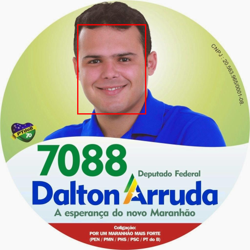
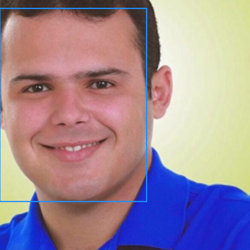
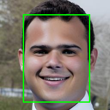
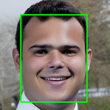
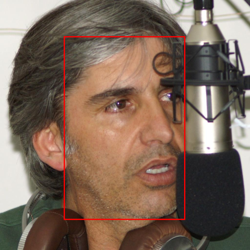
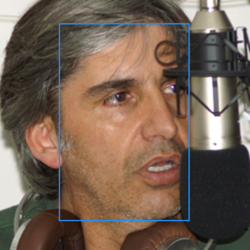
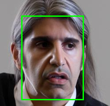
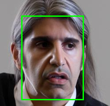
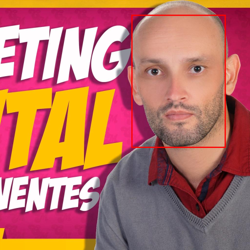
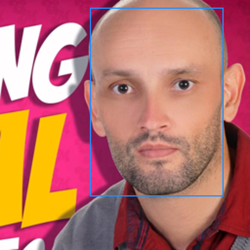
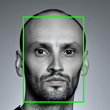
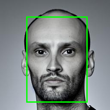
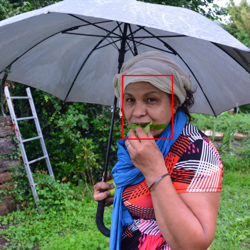
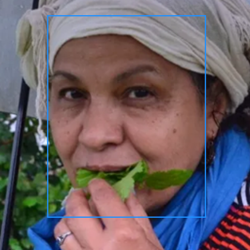
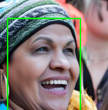
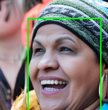
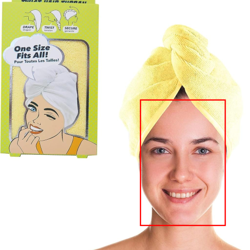
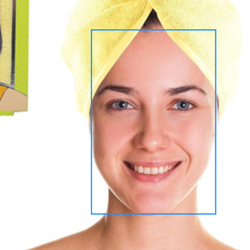
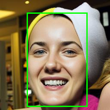
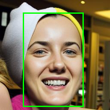

In [26]:
rows = []
for row_n, idx in enumerate(indices, start=1):
    # Use different but deterministic seeds per row. Full/crop modes are fetched separately so each row is reproducible.
    full_item = seeded_getitem(ds_full, idx, SEED + idx)
    crop_item = seeded_getitem(ds_crop, idx, SEED + idx)

    full_target = render_target(full_item, color='red')
    crop_target = render_target(crop_item, color='dodgerblue')
    prompt = html.escape(full_item.get('prompt') or full_item.get('prompts') or '')

    rows.append(f"""
    <tr>
      <td class="idx">{row_n}<br><span>idx={idx}</span></td>
      <td><img src="{img_to_data_uri(full_target, (250, 250))}"><div class="caption">target_crop_256=False</div></td>
      <td><img src="{img_to_data_uri(crop_target, (250, 250))}"><div class="caption">target_crop_256=True</div></td>
      <td>{refs_to_html(full_item)}<div class="caption">refs from full run</div></td>
      <td>{refs_to_html(crop_item)}<div class="caption">refs from crop run</div></td>
      <td class="prompt">{prompt}</td>
    </tr>
    """)

style = """
<style>
.cosmic-table { border-collapse: collapse; font-family: sans-serif; font-size: 13px; }
.cosmic-table th, .cosmic-table td { border: 1px solid #ddd; padding: 6px; vertical-align: top; }
.cosmic-table th { background: #f4f4f4; position: sticky; top: 0; z-index: 1; }
.cosmic-table img { display: block; }
.cosmic-table .idx { min-width: 52px; text-align: center; font-weight: 600; }
.cosmic-table .idx span { font-weight: 400; color: #555; }
.cosmic-table .caption { margin-top: 4px; color: #555; font-size: 12px; }
.cosmic-table .prompt { max-width: 520px; line-height: 1.35; }
</style>
"""

table = f"""
{style}
<p><b>Data source:</b> {html.escape(DATA_SOURCE)} | <b>Rows:</b> {num_rows} | <b>num_refs:</b> {NUM_REFS} | <b>min_face_res:</b> {MIN_FACE_RES}</p>
<table class="cosmic-table">
  <thead>
    <tr>
      <th>#</th>
      <th>Target, no crop<br><span style="color:red">red bbox</span></th>
      <th>Target, 256 crop<br><span style="color:dodgerblue">blue bbox</span></th>
      <th>References, no crop run<br><span style="color:green">green bbox</span></th>
      <th>References, crop run<br><span style="color:green">green bbox</span></th>
      <th>Prompt</th>
    </tr>
  </thead>
  <tbody>
    {''.join(rows)}
  </tbody>
</table>
"""

display(HTML(table))

In [23]:
# Optional: inspect one raw sample dictionary after dataset processing.
inspect_idx = indices[0]
full_item = seeded_getitem(ds_full, inspect_idx, SEED + inspect_idx)
crop_item = seeded_getitem(ds_crop, inspect_idx, SEED + inspect_idx)

summary = {
    'idx': inspect_idx,
    'full_pixel_shape': tuple(full_item['pixel_values'].shape) if torch.is_tensor(full_item['pixel_values']) else full_item['pixel_values'].size,
    'crop_pixel_shape': tuple(crop_item['pixel_values'].shape) if torch.is_tensor(crop_item['pixel_values']) else crop_item['pixel_values'].size,
    'full_face_bbox': [round(float(v), 2) for v in full_item['face_bbox']],
    'crop_face_bbox': [round(float(v), 2) for v in crop_item['face_bbox']],
    'full_original_sizes': full_item.get('original_sizes'),
    'crop_original_sizes': crop_item.get('original_sizes'),
    'full_crop_top_lefts': full_item.get('crop_top_lefts'),
    'crop_crop_top_lefts': crop_item.get('crop_top_lefts'),
    'prompt': full_item.get('prompt'),
}
summary

{'idx': 0,
 'full_pixel_shape': (3, 1024, 1024),
 'crop_pixel_shape': (3, 1024, 1024),
 'full_face_bbox': [320.0, 103.0, 594.0, 464.0],
 'crop_face_bbox': [1.54, 36.52, 598.8, 823.43],
 'full_original_sizes': (1024, 1024),
 'crop_original_sizes': (1024, 1024),
 'full_crop_top_lefts': (0, 0),
 'crop_crop_top_lefts': (0, 0),
 'prompt': 'The person img has short black hair, neatly styled, youthful face, friendly smile revealing white teeth, dark expressive eyes, cheerful and approachable demeanor, wears a bright blue collared shirt, upper body visible, facing camera directly, arms relaxed by sides, upright posture, neat and professional clothing, light green circular backdrop with text and logos, including political party emblem and campaign slogans, clean and focused design'}